In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")
print(df.shape)
print(df.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [6]:
# Check missing values
print(df.isnull().sum())

# Check data types
print(df.dtypes)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
# Basic statistics
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [8]:
# Rename the BOM column issue we saw in SQL
df.rename(columns={df.columns[0]: 'Age'}, inplace=True)

# Check attrition value counts
print(df['Attrition'].value_counts())

# Convert Attrition to numeric for calculations
df['Attrition_Flag'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print("Attrition Rate:", round(df['Attrition_Flag'].mean() * 100, 2), "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12 %


C:\Users\Ritik\AppData\Local\Temp\ipykernel_15128\975732151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette=['#2ecc71', '#e74c3c'])


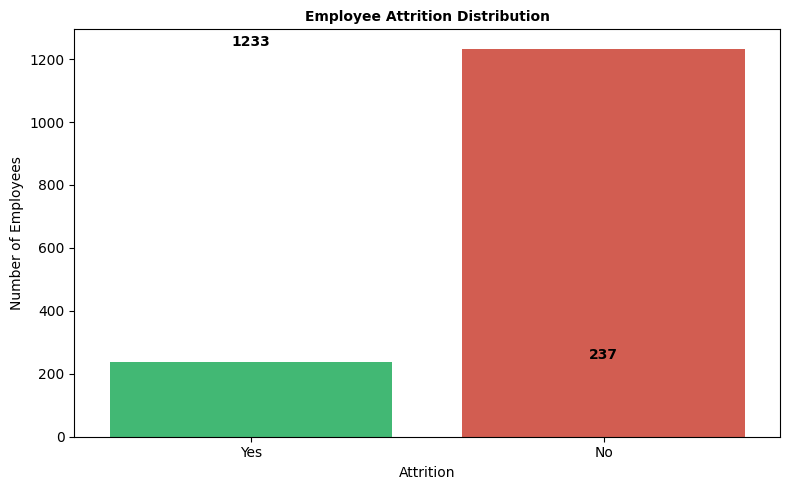

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Employee Attrition Distribution', fontsize=10,fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

# Add numbers on top of bars
for i, v in enumerate(df['Attrition'].value_counts()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=150)
plt.show()

C:\Users\Ritik\AppData\Local\Temp\ipykernel_15128\424614371.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_attrition.reset_index(), x='Department', y='attrition_rate', palette='Reds_d')


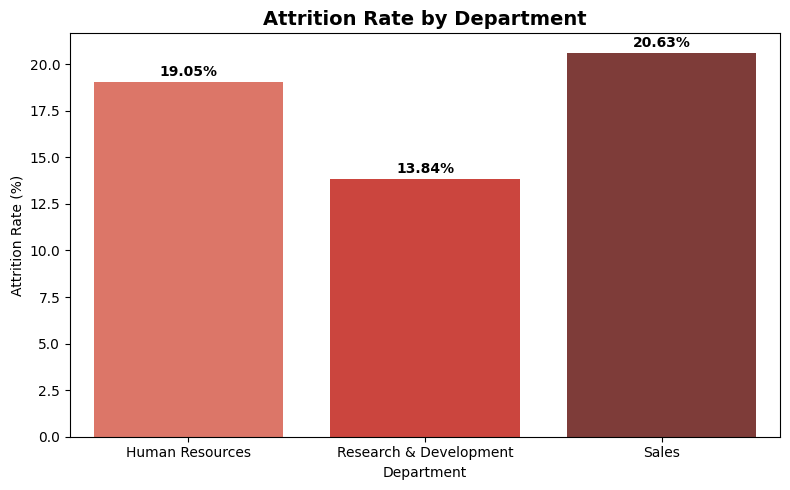

In [12]:
dept_attrition = df.groupby('Department')['Attrition_Flag'].agg(['sum', 'count'])
dept_attrition['attrition_rate'] = round(dept_attrition['sum'] / dept_attrition['count'] * 100, 2)
dept_attrition.columns = ['attrition_count', 'total', 'attrition_rate']

plt.figure(figsize=(8, 5))
sns.barplot(data=dept_attrition.reset_index(), x='Department', y='attrition_rate', palette='Reds_d')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')

for i, v in enumerate(dept_attrition['attrition_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_by_department.png', dpi=150)
plt.show()

C:\Users\Ritik\AppData\Local\Temp\ipykernel_15128\3684806212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overtime_attrition.reset_index(), x='OverTime', y='attrition_rate', palette=['#2ecc71', '#e74c3c'])


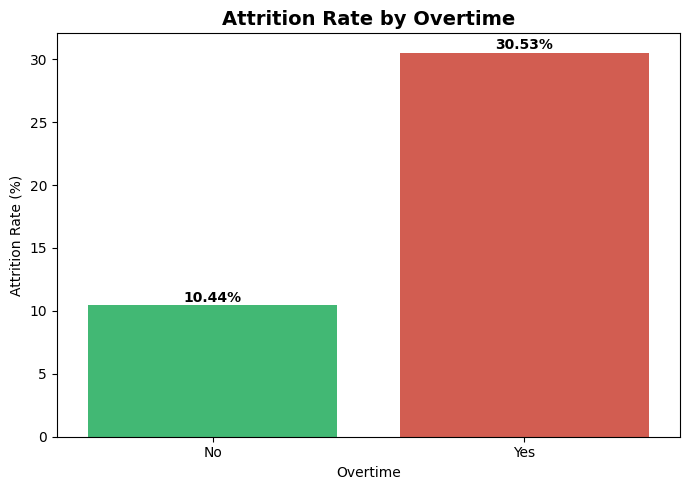

In [13]:
overtime_attrition = df.groupby('OverTime')['Attrition_Flag'].agg(['sum', 'count'])
overtime_attrition['attrition_rate'] = round(overtime_attrition['sum'] / overtime_attrition['count'] * 100, 2)

plt.figure(figsize=(7, 5))
sns.barplot(data=overtime_attrition.reset_index(), x='OverTime', y='attrition_rate', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition Rate by Overtime', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

for i, v in enumerate(overtime_attrition['attrition_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_by_overtime.png', dpi=150)
plt.show()

C:\Users\Ritik\AppData\Local\Temp\ipykernel_15128\3880293788.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('Age_Group')['Attrition_Flag'].agg(['sum', 'count'])
C:\Users\Ritik\AppData\Local\Temp\ipykernel_15128\3880293788.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_attrition.reset_index(), x='Age_Group', y='attrition_rate', palette='Blues_d')


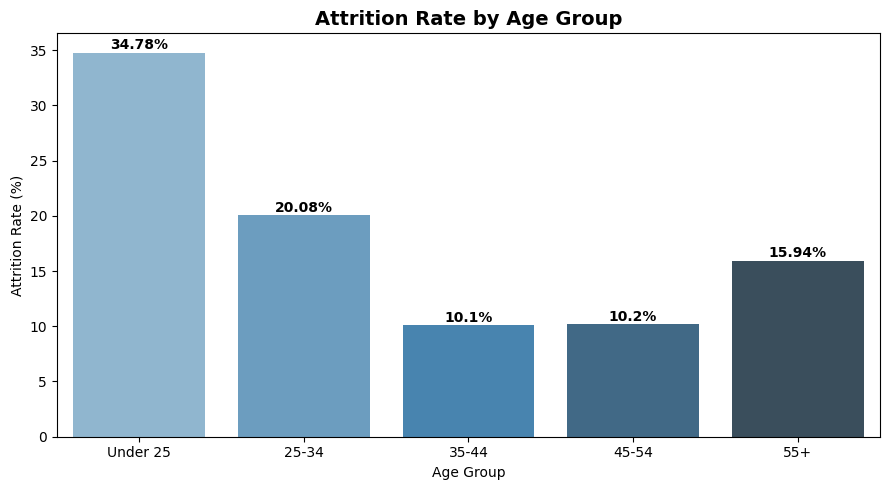

In [15]:
df['Age_Group'] = pd.cut(df['Age'], 
                          bins=[18, 25, 34, 44, 54, 65],
                          labels=['Under 25', '25-34', '35-44', '45-54', '55+'])

age_attrition = df.groupby('Age_Group')['Attrition_Flag'].agg(['sum', 'count'])
age_attrition['attrition_rate'] = round(age_attrition['sum'] / age_attrition['count'] * 100, 2)

plt.figure(figsize=(9, 5))
sns.barplot(data=age_attrition.reset_index(), x='Age_Group', y='attrition_rate', palette='Blues_d')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')

for i, v in enumerate(age_attrition['attrition_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_by_age.png', dpi=150)
plt.show()

C:\Users\Ritik\AppData\Local\Temp\ipykernel_15128\169868981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=travel_attrition.reset_index(), x='BusinessTravel', y='attrition_rate', palette='Oranges_d')


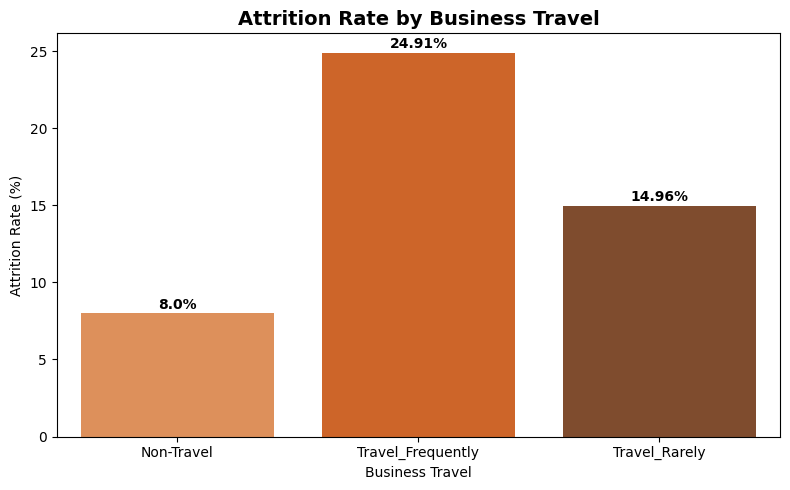

In [16]:
travel_attrition = df.groupby('BusinessTravel')['Attrition_Flag'].agg(['sum', 'count'])
travel_attrition['attrition_rate'] = round(travel_attrition['sum'] / travel_attrition['count'] * 100, 2)

plt.figure(figsize=(8, 5))
sns.barplot(data=travel_attrition.reset_index(), x='BusinessTravel', y='attrition_rate', palette='Oranges_d')
plt.title('Attrition Rate by Business Travel', fontsize=14, fontweight='bold')
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')

for i, v in enumerate(travel_attrition['attrition_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_by_travel.png', dpi=150)
plt.show()

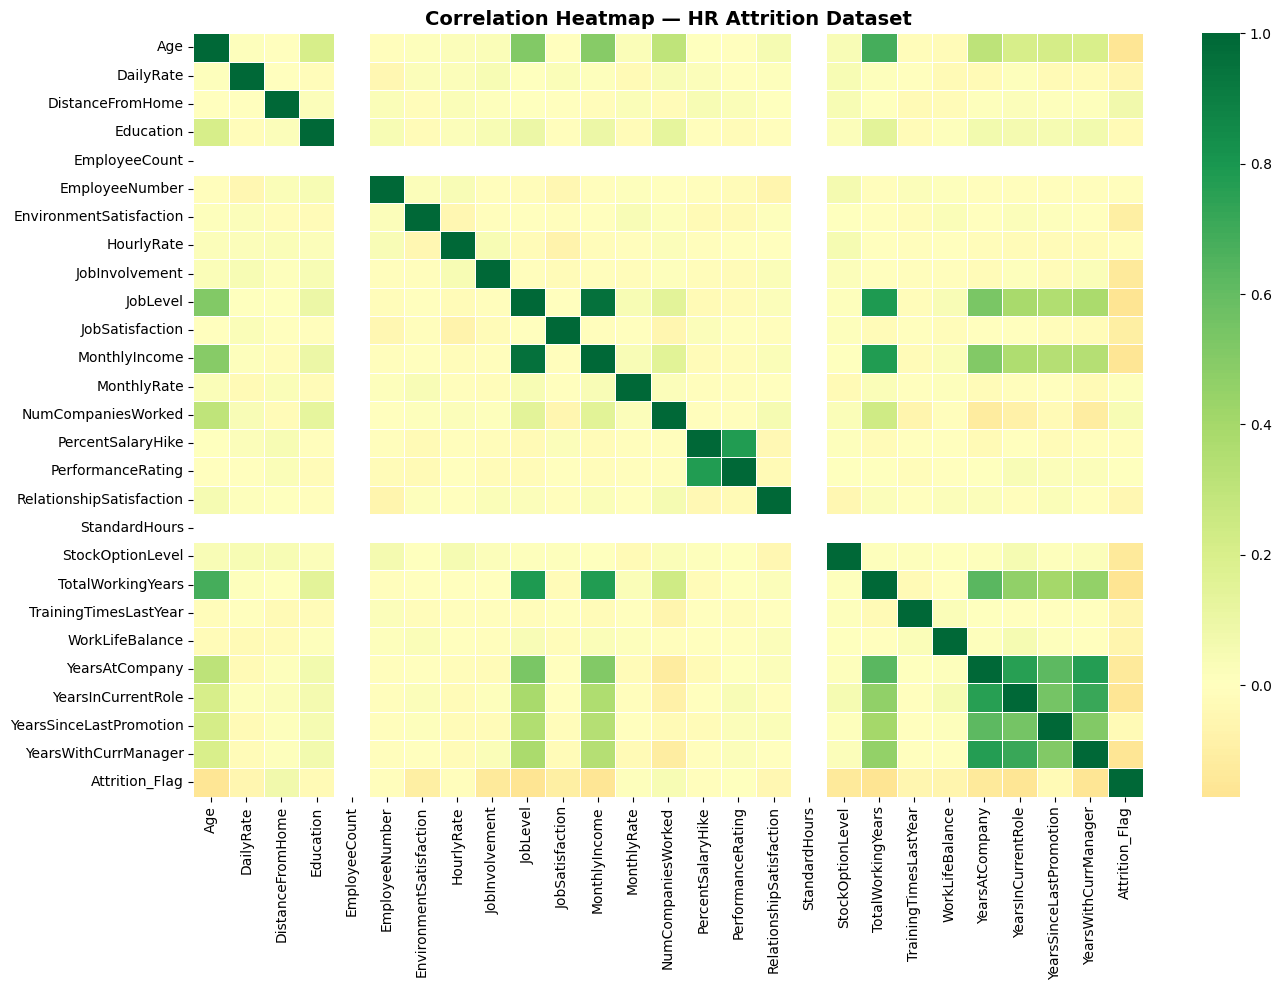

In [17]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), 
            annot=False,
            cmap='RdYlGn',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — HR Attrition Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()